<a href="https://colab.research.google.com/github/lucky-kid-esc/soft-computing/blob/main/multi_objective_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Objective Feature Selection with Bio-Inspired Algorithms
**Dataset:** UCI Human Activity Recognition using Smartphones (10,299 records, 561 features, 6 classes)

**Objectives (all minimised):**
1. Classification error
2. Number of selected features
3. Computational cost (feature-extraction cost of the chosen subset)

**Algorithms compared:** NSGA-II (GA baseline), MOGWO (grey wolf), MOWOA (whale, aquatic), MOBA (bat), MOACO (ant colony)

Run all cells top to bottom (Runtime > Run all). Default settings take roughly 10-20 minutes on free Colab.
For the final report raise `RUNS` and `ITERS` in the next cell.

## 1. Imports and configuration

In [ ]:
import time, io, zipfile, urllib.request, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import f_classif
warnings.filterwarnings("ignore")

# ---- experiment settings (raise RUNS / ITERS for the final report) ----
POP = 20             # population size (= number of ants)
ITERS = 30           # iterations per algorithm -> evaluation budget = POP * ITERS
RUNS = 3             # independent runs per algorithm (use 10+ for the report)
ARCHIVE_CAP = 40     # max size of the Pareto archive
BASE_SEED = 42
REF = np.array([1.1, 1.1, 1.1])   # hypervolume reference point

## 2. Load the dataset

In [ ]:
def load_har():
    url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    try:
        raw = urllib.request.urlopen(url, timeout=120).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        inner = [n for n in z.namelist() if n.lower().endswith(".zip")]
        if inner:
            z = zipfile.ZipFile(io.BytesIO(z.read(inner[0])))
        find = lambda s: [n for n in z.namelist() if n.endswith(s)][0]
        read = lambda s: pd.read_csv(z.open(find(s)), sep=r"\s+", header=None)
        names = read("features.txt")[1].tolist()
        X = np.vstack([read("train/X_train.txt").values, read("test/X_test.txt").values])
        y = np.concatenate([read("train/y_train.txt").values.ravel(),
                            read("test/y_test.txt").values.ravel()])
        print("Loaded from the UCI repository")
        return X, y, names
    except Exception as e:
        print("UCI download failed:", e, "-> falling back to OpenML")
        from sklearn.datasets import fetch_openml
        d = fetch_openml(data_id=1478, as_frame=True, parser="auto")
        return d.data.values.astype(float), pd.factorize(d.target)[0], [str(c) for c in d.data.columns]


def make_cost(names, D):
    """Feature-extraction cost proxy: time-domain = 1, angle features = 2, frequency-domain (FFT) = 3."""
    cost = np.ones(D)
    if any(n.startswith("fBody") for n in names):
        for i, n in enumerate(names):
            if n.startswith("f"):
                cost[i] = 3.0
            elif n.startswith("angle"):
                cost[i] = 2.0
    else:                       # same feature order as the UCI file
        cost[265:554] = 3.0
        cost[554:] = 2.0
    return cost


X, y, feat_names = load_har()
D = X.shape[1]
print(f"Records: {X.shape[0]} | Features: {D} | Classes: {len(np.unique(y))}")

# hold-out test set (never seen by the optimiser)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
sc = StandardScaler().fit(Xtr)
Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)

# smaller fit / validation subsets used *inside* the optimiser (keeps every evaluation fast)
Xf, Xv, yf, yv = train_test_split(Xtr, ytr, train_size=2000, test_size=1000, stratify=ytr, random_state=1)

cost_raw = make_cost(feat_names, D)
print(f"Train {len(ytr)} | Test {len(yte)} | optimiser fit/val {len(yf)}/{len(yv)}")
print(f"Features by cost: time-domain={int((cost_raw==1).sum())}, angle={int((cost_raw==2).sum())}, frequency={int((cost_raw==3).sum())}")

Loaded from the UCI repository
Records: 10299 | Features: 561 | Classes: 6
Train 7209 | Test 3090 | optimiser fit/val 2000/1000
Features by cost: time-domain=265, angle=7, frequency=289


## 3. Problem definition (the 3 objectives)
For a binary vector `x` of length 561:
`F(x) = [ error(x),  |x| / 561,  cost(x) / total_cost ]`, all to be minimised.
`error` is the validation error of a 5-NN classifier trained on the selected features only.

In [ ]:
class FSProblem:
    def __init__(self, Xf, yf, Xv, yv, cost):
        self.Xf, self.yf, self.Xv, self.yv = Xf, yf, Xv, yv
        self.cost = cost / cost.sum()
        self.D = Xf.shape[1]
        self.cache, self.calls = {}, 0

    def reset(self):
        self.cache, self.calls = {}, 0

    def evaluate(self, mask):
        self.calls += 1
        key = mask.tobytes()
        if key in self.cache:
            return self.cache[key]
        idx = np.flatnonzero(mask)
        clf = KNeighborsClassifier(n_neighbors=5, algorithm="brute").fit(self.Xf[:, idx], self.yf)
        err = 1.0 - clf.score(self.Xv[:, idx], self.yv)
        F = np.array([err, mask.sum() / self.D, self.cost[idx].sum()])
        self.cache[key] = F
        return F


problem = FSProblem(Xf, yf, Xv, yv, cost_raw)

## 4. Multi-objective utilities (dominance, archive, hypervolume, IGD)

In [ ]:
def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)

def nd_mask(F):
    keep = np.ones(len(F), bool)
    for i in range(len(F)):
        if (np.all(F <= F[i], axis=1) & np.any(F < F[i], axis=1)).any():
            keep[i] = False
    return keep

def crowding(F):
    n, m = F.shape
    if n <= 2:
        return np.full(n, np.inf)
    d = np.zeros(n)
    for j in range(m):
        idx = np.argsort(F[:, j])
        span = F[idx[-1], j] - F[idx[0], j]
        d[idx[0]] = d[idx[-1]] = np.inf
        if span > 0:
            d[idx[1:-1]] += (F[idx[2:], j] - F[idx[:-2], j]) / span
    return d

def nd_sort(F):
    N = len(F)
    dom = [[] for _ in range(N)]
    cnt = np.zeros(N, int)
    fronts = [[]]
    for p in range(N):
        for q in range(N):
            if dominates(F[p], F[q]):
                dom[p].append(q)
            elif dominates(F[q], F[p]):
                cnt[p] += 1
        if cnt[p] == 0:
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in dom[p]:
                cnt[q] -= 1
                if cnt[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)
    return fronts[:-1]

def hv2d(P, ref):
    P = P[np.argsort(P[:, 0])]
    hv, prev = 0.0, ref[1]
    for x, yv_ in P:
        if yv_ < prev:
            hv += (ref[0] - x) * (prev - yv_)
            prev = yv_
    return hv

def hv3d(F, ref):
    """Exact hypervolume for 3 minimised objectives (slicing)."""
    F = F[np.all(F < ref, axis=1)]
    if len(F) == 0:
        return 0.0
    F = F[np.argsort(F[:, 2])]
    hv = 0.0
    for i in range(len(F)):
        z_next = F[i + 1, 2] if i + 1 < len(F) else ref[2]
        hv += hv2d(F[:i + 1, :2], ref[:2]) * (z_next - F[i, 2])
    return hv

def igd(front, refpf, lo, hi):
    A = (front - lo) / (hi - lo + 1e-12)
    R = (refpf - lo) / (hi - lo + 1e-12)
    return np.sqrt(((R[:, None, :] - A[None, :, :]) ** 2).sum(-1)).min(1).mean()


class Archive:
    """External archive of non-dominated solutions (used by all algorithms)."""
    def __init__(self, cap):
        self.cap, self.M, self.F = cap, [], []

    def __len__(self):
        return len(self.F)

    def add(self, mask, f):
        f = np.asarray(f)
        if self.F:
            Fa = np.array(self.F)
            if np.any(np.all(Fa <= f, axis=1)):       # dominated or duplicate
                return
            keep = ~np.all(f <= Fa, axis=1)           # drop members dominated by the new one
            self.M = [m for m, k in zip(self.M, keep) if k]
            self.F = [x for x, k in zip(self.F, keep) if k]
        self.M.append(mask.copy())
        self.F.append(f)
        if len(self.F) > self.cap:                    # prune the most crowded member
            worst = int(np.argmin(crowding(np.array(self.F))))
            del self.M[worst], self.F[worst]

    def F_array(self): return np.array(self.F)
    def M_array(self): return np.array(self.M)
    def pos_array(self): return np.where(self.M_array(), 0.85, 0.15)   # leader positions for swarm moves
    def hv(self): return hv3d(self.F_array(), REF)

## 5. Shared helpers for binary encoding

In [ ]:
def binarize(pos, rng):
    """S-shaped transfer function: continuous position in [0,1] -> binary mask."""
    return rng.random(pos.shape) < 1.0 / (1.0 + np.exp(-10.0 * (pos - 0.5)))

def repair(mask, rng):
    if not mask.any():
        mask[rng.integers(len(mask))] = True
    return mask

def init_positions(n, D, rng):
    """Random initial subsets with varied density (2%-50% of features) for a diverse start."""
    dens = rng.uniform(0.02, 0.5, size=(n, 1))
    bits = rng.random((n, D)) < dens
    return np.where(bits, rng.uniform(0.7, 1.0, (n, D)), rng.uniform(0.0, 0.3, (n, D)))

def eval_pop(problem, pos, rng):
    masks = np.array([repair(binarize(p, rng), rng) for p in pos])
    F = np.array([problem.evaluate(m) for m in masks])
    return masks, F

def upd(arc, masks, F):
    for m, f in zip(masks, F):
        arc.add(m, f)

## 6. The five algorithms
All use the same budget (`POP x ITERS` evaluations), the same archive and the same three objectives.

In [ ]:
# ---------- MOGWO: multi-objective Grey Wolf Optimiser ----------
def mogwo(problem, rng):
    D = problem.D
    pos = init_positions(POP, D, rng)
    arc = Archive(ARCHIVE_CAP)
    masks, F = eval_pop(problem, pos, rng)
    upd(arc, masks, F)
    hist = [arc.hv()]
    for t in range(1, ITERS):
        a = 2.0 * (1 - t / ITERS)
        L = arc.pos_array()
        new = np.empty_like(pos)
        for i in range(POP):
            xs = []
            for k in rng.integers(len(L), size=3):        # alpha, beta, delta picked from the archive
                A = 2 * a * rng.random(D) - a
                C = 2 * rng.random(D)
                xs.append(L[k] - A * np.abs(C * L[k] - pos[i]))
            new[i] = np.mean(xs, axis=0)
        pos = np.clip(new, 0, 1)
        masks, F = eval_pop(problem, pos, rng)
        upd(arc, masks, F)
        hist.append(arc.hv())
    return arc, hist


# ---------- MOWOA: multi-objective Whale Optimisation Algorithm (aquatic) ----------
def mowoa(problem, rng):
    D = problem.D
    pos = init_positions(POP, D, rng)
    arc = Archive(ARCHIVE_CAP)
    masks, F = eval_pop(problem, pos, rng)
    upd(arc, masks, F)
    hist = [arc.hv()]
    for t in range(1, ITERS):
        a = 2.0 * (1 - t / ITERS)
        a2 = -1.0 - t / ITERS
        L = arc.pos_array()
        new = np.empty_like(pos)
        for i in range(POP):
            Xs = L[rng.integers(len(L))]                  # "prey" = random archive member
            if rng.random() < 0.5:                        # encircling / random search
                A = 2 * a * rng.random(D) - a
                C = 2 * rng.random(D)
                a_scalar = 2 * a * rng.random() - a
                ref = Xs if abs(a_scalar) < 1 else pos[rng.integers(POP)]
                new[i] = ref - A * np.abs(C * ref - pos[i])
            else:                                         # bubble-net spiral
                l = (a2 - 1) * rng.random() + 1
                new[i] = np.abs(Xs - pos[i]) * np.exp(l) * np.cos(2 * np.pi * l) + Xs
        pos = np.clip(new, 0, 1)
        masks, F = eval_pop(problem, pos, rng)
        upd(arc, masks, F)
        hist.append(arc.hv())
    return arc, hist


# ---------- MOBA: multi-objective Bat Algorithm ----------
def moba(problem, rng):
    D = problem.D
    fmin, fmax, alpha, gamma, r0 = 0.0, 2.0, 0.9, 0.9, 0.5
    pos = init_positions(POP, D, rng)
    vel = np.zeros((POP, D))
    loud = np.ones(POP)
    arc = Archive(ARCHIVE_CAP)
    masks, Fcur = eval_pop(problem, pos, rng)
    upd(arc, masks, Fcur)
    hist = [arc.hv()]
    for t in range(1, ITERS):
        rate = r0 * (1 - np.exp(-gamma * t))
        L = arc.pos_array()
        cand = np.empty_like(pos)
        for i in range(POP):
            Xs = L[rng.integers(len(L))]
            f = fmin + (fmax - fmin) * rng.random()       # echolocation frequency
            vel[i] = np.clip(vel[i] + (Xs - pos[i]) * f, -0.5, 0.5)
            cand[i] = np.clip(pos[i] + vel[i], 0, 1)
            if rng.random() > rate:                    # local random walk around a leader
                cand[i] = np.clip(Xs + 0.1 * loud.mean() * rng.normal(size=D), 0, 1)
        masks, F = eval_pop(problem, cand, rng)
        upd(arc, masks, F)
        for i in range(POP):                              # accept if not dominated (and loud enough)
            if not dominates(Fcur[i], F[i]) and rng.random() < loud[i]:
                pos[i], Fcur[i] = cand[i], F[i]
                loud[i] *= alpha
        hist.append(arc.hv())
    return arc, hist


# ---------- NSGA-II: genetic-algorithm baseline ----------
def rank_crowd(F):
    rank, crowd = np.zeros(len(F), int), np.zeros(len(F))
    for r, fr in enumerate(nd_sort(F)):
        rank[fr] = r
        crowd[fr] = crowding(F[fr])
    return rank, crowd

def env_select(F, n):
    sel = []
    for fr in nd_sort(F):
        if len(sel) + len(fr) <= n:
            sel += fr
        else:
            order = np.argsort(-crowding(F[fr]))
            sel += [fr[i] for i in order[:n - len(sel)]]
            break
    return np.array(sel)

def nsga2(problem, rng):
    D = problem.D
    dens = rng.uniform(0.02, 0.5, (POP, 1))
    P = np.array([repair(m, rng) for m in (rng.random((POP, D)) < dens)])
    F = np.array([problem.evaluate(m) for m in P])
    arc = Archive(ARCHIVE_CAP)
    upd(arc, P, F)
    hist = [arc.hv()]
    pm = 2.0 / D
    for t in range(1, ITERS):
        rank, crowd = rank_crowd(F)
        def pick():
            a, b = rng.integers(len(P), size=2)
            return a if (rank[a] < rank[b] or (rank[a] == rank[b] and crowd[a] > crowd[b])) else b
        O = []
        while len(O) < POP:
            p1, p2 = P[pick()], P[pick()]
            if rng.random() < 0.9:                        # uniform crossover
                sw = rng.random(D) < 0.5
                kids = (np.where(sw, p1, p2), np.where(sw, p2, p1))
            else:
                kids = (p1.copy(), p2.copy())
            for c in kids:                                # bit-flip mutation
                O.append(repair(np.logical_xor(c, rng.random(D) < pm), rng))
        O = np.array(O[:POP])
        FO = np.array([problem.evaluate(m) for m in O])
        upd(arc, O, FO)
        allP, allF = np.vstack([P, O]), np.vstack([F, FO])
        sel = env_select(allF, POP)
        P, F = allP[sel], allF[sel]
        hist.append(arc.hv())
    return arc, hist


# ---------- MOACO: multi-objective Ant Colony Optimisation ----------
Fsc, _ = f_classif(Xf, yf)
Fsc = np.nan_to_num(Fsc)
ETA1 = np.clip(0.05 + 0.95 * np.sqrt(Fsc / Fsc.max()) * (1 - 0.5 * cost_raw / cost_raw.max()), 0.02, 0.98)
ETA0 = 1.0 - ETA1     # heuristic: relevant (ANOVA F-score) and cheap features are more attractive

def moaco(problem, rng):
    D = problem.D
    a_, b_, rho, tmin, tmax = 1.0, 1.0, 0.15, 0.05, 1.0
    tau = np.full((D, 2), 0.5)                            # [:,0] = skip feature, [:,1] = take feature
    arc = Archive(ARCHIVE_CAP)
    hist = []
    for t in range(ITERS):
        s = tau[:, 1] ** a_ * ETA1 ** b_
        n = tau[:, 0] ** a_ * ETA0 ** b_
        p = s / (s + n)
        masks = []
        for k in range(POP):
            g = rng.uniform(0.3, 4.0)                     # per-ant selectivity -> subsets of varied size
            masks.append(repair(rng.random(D) < p ** g, rng))
        masks = np.array(masks)
        F = np.array([problem.evaluate(m) for m in masks])
        upd(arc, masks, F)
        tau *= (1 - rho)                                  # evaporation
        elite = arc.M_array()[rng.choice(len(arc), size=min(5, len(arc)), replace=False)]
        for m in elite:                                   # deposit from Pareto-archive members
            tau[m, 1] += rho / len(elite)
            tau[~m, 0] += rho / len(elite)
        tau = np.clip(tau, tmin, tmax)
        hist.append(arc.hv())
    return arc, hist

## 7. Run the experiment

In [ ]:
ALGOS = {"NSGA-II": nsga2, "MOGWO": mogwo, "MOWOA": mowoa, "MOBA": moba, "MOACO": moaco}
results = {n: [] for n in ALGOS}
T0 = time.time()
for run in range(RUNS):
    for name, fn in ALGOS.items():
        rng = np.random.default_rng(BASE_SEED + run)
        problem.reset()
        t0 = time.time()
        arc, hist = fn(problem, rng)
        rt = time.time() - t0
        results[name].append(dict(M=arc.M_array(), F=arc.F_array(), hist=hist, time=rt, calls=problem.calls))
        print(f"run {run+1}/{RUNS} | {name:8s} | front size {len(arc):3d} | HV {hist[-1]:.4f} | "
              f"{rt:6.1f}s | evals {problem.calls}")
print(f"Total time: {(time.time()-T0)/60:.1f} min")

run 1/3 | NSGA-II  | front size  15 | HV 1.1274 |   27.9s | evals 600
run 1/3 | MOGWO    | front size  15 | HV 1.0379 |   18.9s | evals 600
run 1/3 | MOWOA    | front size  24 | HV 1.2211 |   17.5s | evals 600
run 1/3 | MOBA     | front size  24 | HV 0.9758 |   22.7s | evals 600
run 1/3 | MOACO    | front size  11 | HV 1.2377 |   10.4s | evals 600
run 2/3 | NSGA-II  | front size  25 | HV 1.2075 |   15.0s | evals 600
run 2/3 | MOGWO    | front size  18 | HV 1.1051 |   17.4s | evals 600
run 2/3 | MOWOA    | front size  19 | HV 1.2072 |   17.2s | evals 600
run 2/3 | MOBA     | front size  14 | HV 1.0704 |   20.5s | evals 600
run 2/3 | MOACO    | front size   9 | HV 1.2358 |    7.4s | evals 600
run 3/3 | NSGA-II  | front size  25 | HV 1.1984 |   13.4s | evals 600
run 3/3 | MOGWO    | front size  11 | HV 1.0933 |   18.9s | evals 600
run 3/3 | MOWOA    | front size  20 | HV 1.2280 |   14.6s | evals 600
run 3/3 | MOBA     | front size  30 | HV 1.0230 |   21.8s | evals 600
run 3/3 | MOACO    |

## 8. Compare the algorithms
Metrics: hypervolume (higher = better), IGD (lower = better), runtime, and the smallest feature subset whose
validation error stays within 2 percentage points of the all-features baseline. The "knee" solution
(closest to the ideal point) of each algorithm is then checked on the untouched test set.

In [ ]:
names = list(ALGOS)
allF = np.unique(np.vstack([r["F"] for n in names for r in results[n]]), axis=0)
REFPF = allF[nd_mask(allF)]                               # reference front = union of every front found
lo, hi = REFPF.min(0), REFPF.max(0)

problem.reset()
Fb = problem.evaluate(np.ones(D, bool))
tol = Fb[0] + 0.02

def test_eval(mask):
    idx = np.flatnonzero(mask)
    clf = KNeighborsClassifier(n_neighbors=5, algorithm="brute").fit(Xtr[:, idx], ytr)
    t0 = time.time()
    pred = clf.predict(Xte[:, idx])
    return (pred == yte).mean(), time.time() - t0

base_acc, base_t = test_eval(np.ones(D, bool))

rows, hvs, fronts, knees = [], {}, {}, {}
for n in names:
    R = results[n]
    hv = [hv3d(r["F"], REF) for r in R]
    hvs[n] = hv
    ig = [igd(r["F"], REFPF, lo, hi) for r in R]
    mf = [r["F"][r["F"][:, 0] <= tol, 1].min() * D if (r["F"][:, 0] <= tol).any() else np.nan for r in R]
    Mp = np.vstack([r["M"] for r in R]); Fp = np.vstack([r["F"] for r in R])
    keep = nd_mask(Fp); Mp, Fp = Mp[keep], Fp[keep]
    _, ui = np.unique(Fp, axis=0, return_index=True); Mp, Fp = Mp[ui], Fp[ui]
    fronts[n] = Fp
    k = int(np.argmin(np.linalg.norm((Fp - lo) / (hi - lo + 1e-12), axis=1)))
    acc, t_inf = test_eval(Mp[k])
    knees[n] = Mp[k]
    rows.append({
        "Algorithm": n,
        "HV (mean)": np.mean(hv), "HV (std)": np.std(hv),
        "IGD (mean)": np.mean(ig),
        "Runtime s": np.mean([r["time"] for r in R]),
        "Front size": np.mean([len(r["F"]) for r in R]),
        f"Min feats @ err<=base+2%": np.nanmean(mf) if not np.all(np.isnan(mf)) else np.nan,
        "Knee: #features": int(Mp[k].sum()),
        "Knee: cost frac": Fp[k][2],
        "Knee: test acc": acc,
        "Knee: inference ms": t_inf * 1000,
    })

table = pd.DataFrame(rows).set_index("Algorithm")
print(f"Baseline (all {D} features): validation error {Fb[0]:.4f} | test accuracy {base_acc:.4f} | inference {base_t*1000:.0f} ms")
display(table.round(4))
table.round(4).to_csv("results_table.csv")

if RUNS >= 3:
    stat, pval = friedmanchisquare(*[hvs[n] for n in names])
    print(f"Friedman test on hypervolume: chi2 = {stat:.3f}, p = {pval:.4f}")
ranks = pd.DataFrame(hvs).rank(axis=1, ascending=False).mean()
print("Mean HV rank per algorithm (1 = best):")
print(ranks.sort_values().round(2).to_string())
best = table["HV (mean)"].idxmax()
print(f"\nBest algorithm by mean hypervolume: {best}")

Baseline (all 561 features): validation error 0.0880 | test accuracy 0.9628 | inference 953 ms


,HV (mean),HV (std),IGD (mean),Runtime s,Front size,Min feats @ err<=base+2%,Knee: #features,Knee: cost frac,Knee: test acc,Knee: inference ms
Algorithm,,,,,,,,,,
NSGA-II,1.1778,0.0358,0.2618,18.7506,21.6667,28.0000,16,0.0288,0.8994,119.7336
MOGWO,1.0788,0.0293,0.5366,18.4088,14.6667,56.6667,41,0.0593,0.8757,153.0914
MOWOA,1.2188,0.0086,0.1470,16.4572,21.0000,36.6667,9,0.0148,0.8573,109.7515
MOBA,1.0230,0.0386,0.7257,21.6707,22.6667,78.6667,45,0.0724,0.8515,171.4516
MOACO,1.2378,0.0017,0.1626,12.8340,10.0000,6.6667,7,0.0061,0.9230,110.5011


Friedman test on hypervolume: chi2 = 11.467, p = 0.0218
Mean HV rank per algorithm (1 = best):
MOACO      1.00
MOWOA      2.33
NSGA-II    2.67
MOGWO      4.00
MOBA       5.00

Best algorithm by mean hypervolume: MOACO


## 9. Plots

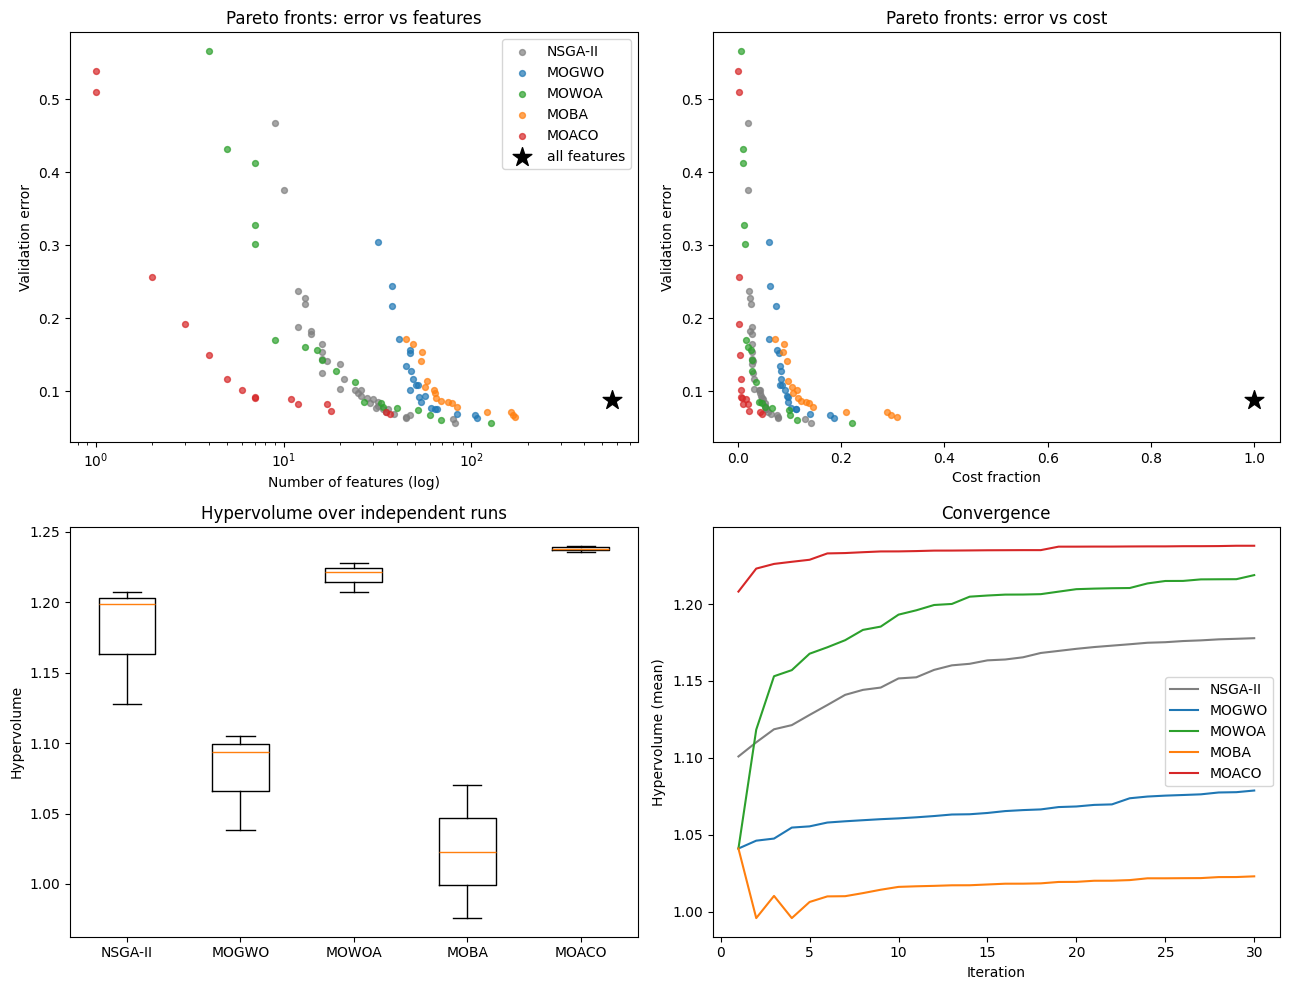

In [ ]:
colors = dict(zip(names, ["tab:gray", "tab:blue", "tab:green", "tab:orange", "tab:red"]))
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
for n in names:
    Fp = fronts[n]
    ax[0, 0].scatter(Fp[:, 1] * D, Fp[:, 0], s=18, alpha=.7, c=colors[n], label=n)
    ax[0, 1].scatter(Fp[:, 2], Fp[:, 0], s=18, alpha=.7, c=colors[n], label=n)
ax[0, 0].scatter([D], [Fb[0]], marker="*", s=200, c="k", label="all features")
ax[0, 0].set_xscale("log"); ax[0, 0].set_xlabel("Number of features (log)"); ax[0, 0].set_ylabel("Validation error")
ax[0, 0].set_title("Pareto fronts: error vs features"); ax[0, 0].legend()
ax[0, 1].scatter([1.0], [Fb[0]], marker="*", s=200, c="k")
ax[0, 1].set_xlabel("Cost fraction"); ax[0, 1].set_ylabel("Validation error")
ax[0, 1].set_title("Pareto fronts: error vs cost")
ax[1, 0].boxplot([hvs[n] for n in names], labels=names)
ax[1, 0].set_ylabel("Hypervolume"); ax[1, 0].set_title("Hypervolume over independent runs")
for n in names:
    H = np.array([r["hist"] for r in results[n]])
    ax[1, 1].plot(np.arange(1, H.shape[1] + 1), H.mean(0), c=colors[n], label=n)
ax[1, 1].set_xlabel("Iteration"); ax[1, 1].set_ylabel("Hypervolume (mean)")
ax[1, 1].set_title("Convergence"); ax[1, 1].legend()
plt.tight_layout(); plt.savefig("results.png", dpi=150); plt.show()

## 10. Which features survived? (knee solution of the best algorithm)

In [ ]:
mask = knees[best]
sel = np.flatnonzero(mask)
print(f"{best}: {len(sel)} of {D} features kept ({100*len(sel)/D:.1f}%), "
      f"{int((cost_raw[sel]==3).sum())} frequency-domain / {int((cost_raw[sel]==1).sum())} time-domain / "
      f"{int((cost_raw[sel]==2).sum())} angle")
print("First 15 selected features:", [feat_names[i] for i in sel[:15]])

MOACO: 7 of 561 features kept (1.2%), 0 frequency-domain / 7 time-domain / 0 angle
First 15 selected features: ['tGravityAcc-max()-X', 'tGravityAcc-min()-Y', 'tGravityAcc-energy()-X', 'tBodyAccJerk-mad()-Y', 'tBodyAccJerk-sma()', 'tBodyAccMag-std()', 'tBodyGyroJerkMag-entropy()']
